In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.dates as mdates

In [2]:
climate_data = pd.read_csv('../../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_min'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

print('Environmental Data Summary (Manaus, Brazil 2016-2024)')
print('='*60)
print(f"Temperature:  min={temp_actual.min():.1f}°C, max={temp_actual.max():.1f}°C, mean={temp_actual.mean():.1f}°C")
print(f"Humidity:     min={humid_actual.min():.1f}%, max={humid_actual.max():.1f}%, mean={humid_actual.mean():.1f}%")
print(f"Precipitation: min={rain_actual.min():.1f}mm, max={rain_actual.max():.1f}mm, mean={rain_actual.mean():.1f}mm")
print(f"Fire counts:  min={fire_actual.min():.0f}, max={fire_actual.max():.0f}, mean={fire_actual.mean():.1f}")
print(f"Deforestation: min={defor_actual.min():.2f}km², max={defor_actual.max():.2f}km², mean={defor_actual.mean():.2f}km²")
print('='*60)


Environmental Data Summary (Manaus, Brazil 2016-2024)
Temperature:  min=23.1°C, max=32.5°C, mean=26.7°C
Humidity:     min=25.5%, max=93.9%, mean=68.3%
Precipitation: min=0.0mm, max=71.2mm, mean=3.7mm
Fire counts:  min=0, max=169, mean=0.9
Deforestation: min=0.00km², max=8.34km², mean=0.02km²


In [3]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================

T_prime = 16 #19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 24.8 #36.5
A = -0.03
B = 1.31
C = -4.4
b1 = 0.04
b2 = 0.09

DD = 105
Tmin = 14.5
R_L = 32.67
gamma = 1/120

defor_max_effect = 0.30
defor_scale = 0.0001
fire_smoke_effect = 0.40
fire_habitat_effect = 0.20


In [4]:
# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

In [5]:
def tau_L(Temp):
    """Larval development duration - vectorized"""
    Temp = np.asarray(Temp)
    denominator = c1 * Temp + c2
    result = np.where(denominator <= 0, np.inf, 1.0 / denominator)
    return result

def p_T(Temp, Humid, H0=50.0, k=0.08, phi=0.25):
    """Adult survival probability - vectorized
    
    H0 = 50: Midpoint of the sigmoid (humidity where p_H ≈ 0.5)
    k = 0.08: Transition slope (calibrated for umid_min range)
    phi = 0.25: Minimum survival (micro-habitats)

    Compatible with both umid_min and umid_med data.
    """
    Temp = np.asarray(Temp)
    Humid = np.asarray(Humid)
    
    # Calculate p_T_temp (temperature component)
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    # Calculate p_H (humidity component)
    p_H = phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))
    
    return p_T_temp * p_H

def p_LT(Temp):
    """Larval survival probability - vectorized"""
    Temp = np.asarray(Temp)
    exponent = c1 * Temp + c2
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    """Larval development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_ML / R_L**2) * Rain * (R_L - Rain))
    return result

def p_ER(Rain, R_L):
    """Egg development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_ME / R_L**2) * Rain * (R_L - Rain))
    return result

def p_PR(Rain, R_L):
    """Pupae development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_MP / R_L**2) * Rain * (R_L - Rain))
    return result

def tau_M(Temp):
    """Mosquito maturation time - vectorized"""
    Temp = np.asarray(Temp)
    result = np.where(Temp <= Tmin, np.inf, DD / (Temp - Tmin))
    return result

def mu(Temp, Humid, H0=50.0, k=0.08, phi=0.25):
    """Adult mosquito mortality rate - vectorized"""
    Temp = np.asarray(Temp)
    Humid = np.asarray(Humid)
    
    # Calculate p_T_val first
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    # Calculate p_H (humidity component)
    p_H = phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))
    
    p_T_val = p_T_temp * p_H
    
    # Calculate mu
    mu_val = np.where(p_T_val <= 0, np.inf, -np.log(p_T_val))
    return mu_val

def a(Temp):
    """Biting rate - vectorized"""
    Temp = np.asarray(Temp)
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return a_val

def a_with_fire(Temp, fire_counts, fire_smoke_effect):
    """Biting rate with fire effect - vectorized"""
    Temp = np.asarray(Temp)
    fire_counts = np.asarray(fire_counts)
    
    base_rate = a(Temp)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    smoke_reduction = fire_smoke_effect * fire_intensity
    return base_rate * (1 - smoke_reduction)

def b_rate(Rain, Temp, R_L):
    """Birth rate of adult mosquitoes - vectorized"""
    Rain = np.asarray(Rain)
    Temp = np.asarray(Temp)
    
    tau_L_curr = tau_L(Temp)
    
    # Calculate numerator components
    p_ER_val = p_ER(Rain, R_L)
    p_LR_val = p_LR(Rain, R_L)
    p_LT_val = p_LT(Temp)
    p_PR_val = p_PR(Rain, R_L)
    
    numerator = B_E * p_ER_val * p_LR_val * p_LT_val * p_PR_val
    denominator = tau_E + tau_L_curr + tau_P
    
    # Handle division by zero or infinite tau_L
    result = np.where((denominator <= 0) | (tau_L_curr == np.inf), 0.0, 
                      numerator / denominator)
    return result

def b_rate_with_environment(Rain, Temp, R_L, fire_counts, total_degradation):
    """Birth rate with environmental effects - vectorized"""
    Rain = np.asarray(Rain)
    Temp = np.asarray(Temp)
    fire_counts = np.asarray(fire_counts)
    total_degradation = np.asarray(total_degradation)
    
    base_rate = b_rate(Rain, Temp, R_L)
    
    defor_effect = np.minimum(total_degradation * defor_scale, defor_max_effect)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    fire_habitat_destruction = fire_habitat_effect * fire_intensity
    
    net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
    return base_rate * net_effect

def mu_with_fire(Temp, Humid, fire_counts, fire_habitat_effect):
    """Mortality rate with fire effect - vectorized"""
    Temp = np.asarray(Temp)
    Humid = np.asarray(Humid)
    fire_counts = np.asarray(fire_counts)
    
    base_mu = mu(Temp, Humid)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    fire_mortality_increase = 0.15 * fire_intensity
    
    result = np.minimum(base_mu + fire_mortality_increase, 0.5)
    return result

print('Vectorized functions loaded successfully!')

Vectorized functions loaded successfully!


umid_min Distribution (input to p_H sigmoid):
--------------------------------------------------
   1th percentile:  34.7%
   5th percentile:  44.7%
  10th percentile:  52.2%
  25th percentile:  62.5%
  50th percentile:  70.2%
  75th percentile:  76.4%
  90th percentile:  81.3%
  95th percentile:  84.0%
  99th percentile:  88.3%
  Mean:  68.3%
  Range: 25.5% - 93.9%

Mean temperature component p_T_temp = 0.8968 at T=26.7°C

Candidate                                 p_H min  p_H max  p_T min  p_T max   mu min   mu max mu range
------------------------------------------------------------------------------------------------
Original (for umid_med)                     0.050    1.000    0.043    0.903    0.102    3.140    3.038
Smooth (H0=50, k=0.08, phi=0.25)            0.343    0.978    0.295    0.882    0.125    1.220    1.095
Very smooth (H0=50, k=0.06, phi=0.30)       0.431    0.953    0.371    0.859    0.151    0.991    0.839
Moderate (H0=55, k=0.10, phi=0.15)          0.192    0.983 

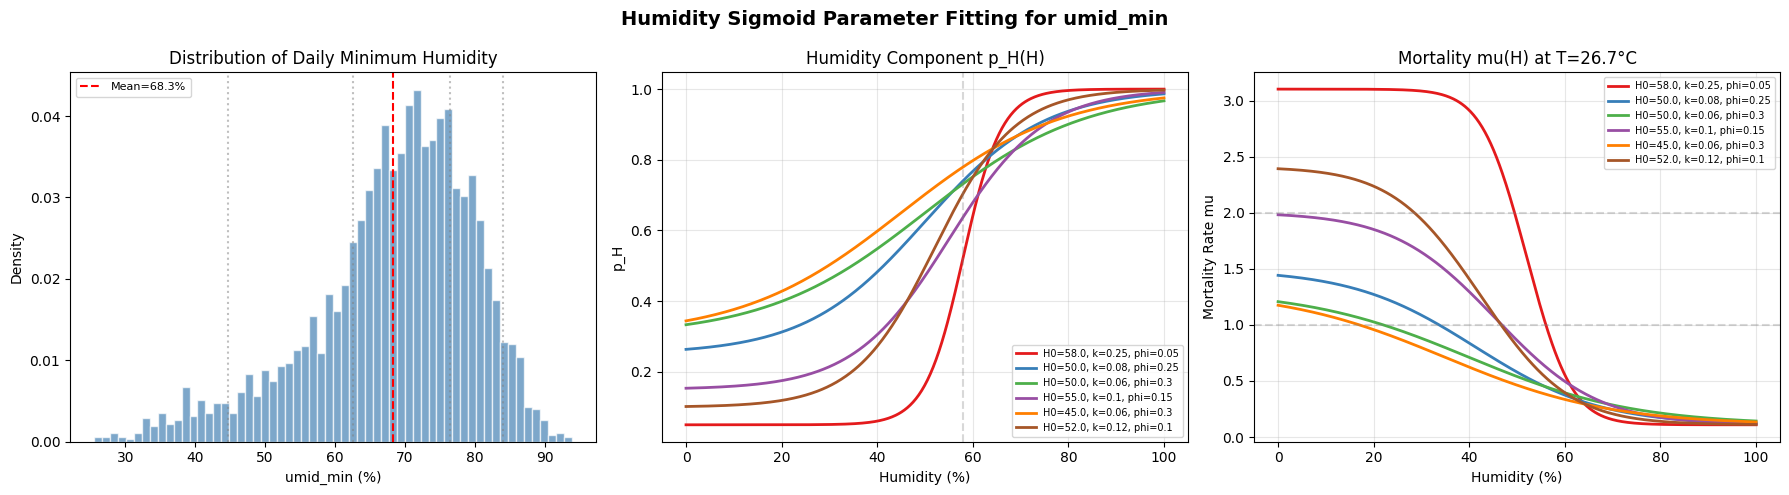

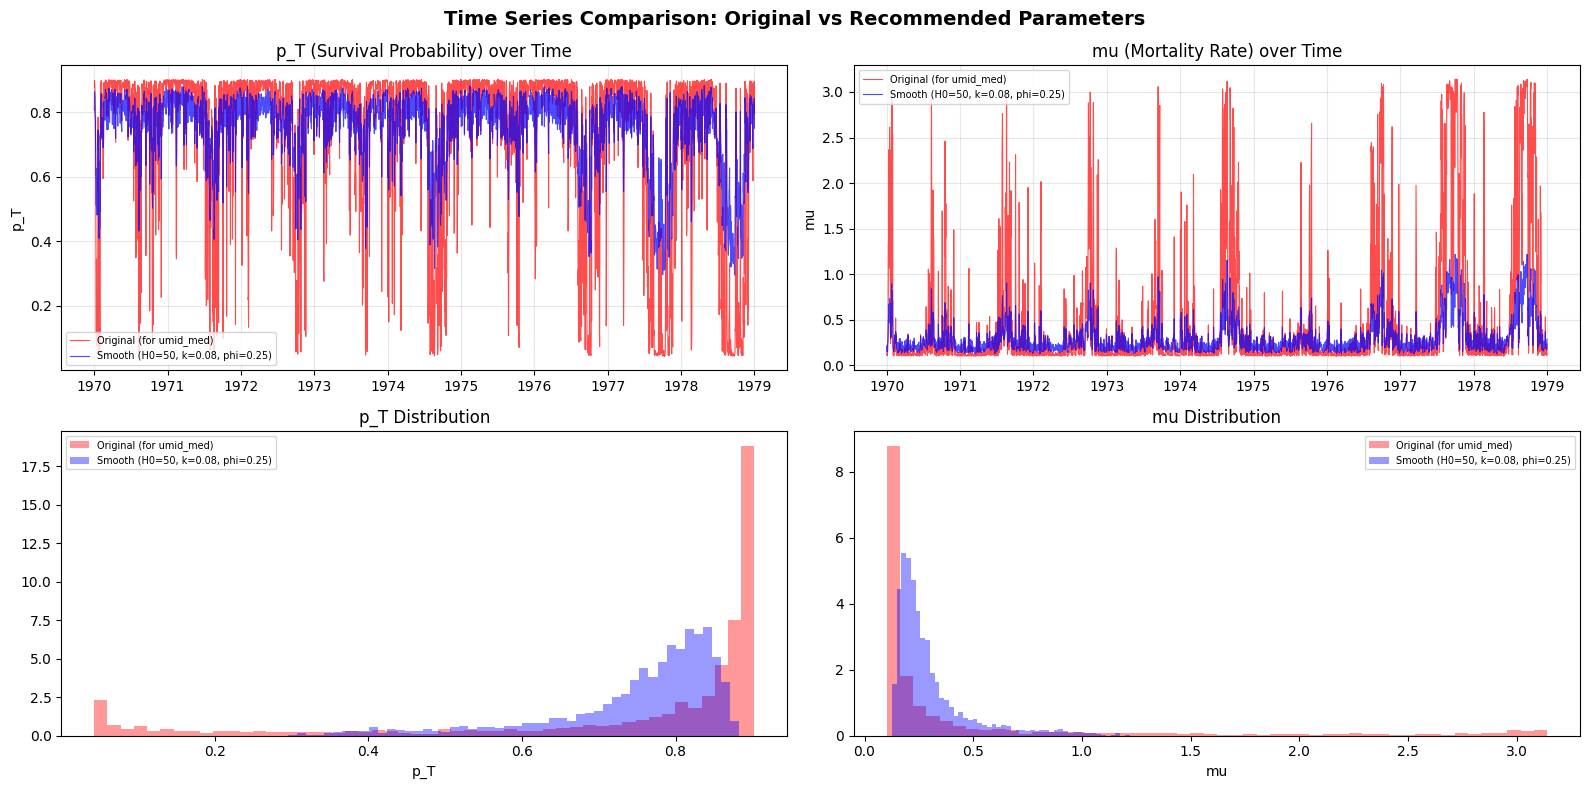

In [6]:
# ============================================================================
# PARAMETER FITTING: Calibrate H0, k, phi for umid_min
# ============================================================================
# The humidity sigmoid:
#   p_H = phi + (1-phi) / (1 + exp(-k * (Humid - H0)))
# 
# Current defaults (H0=58, k=0.25, phi=0.05) were designed for umid_med (~70-90%).
# For umid_min (range: 25-94%), recalibrating keeps p_T and mu from oscillating wildly.
# ============================================================================

humid_data = climate_data['umid_min'].dropna().values
temp_data = climate_data['temp_med'].dropna().values

# --- Data distribution ---
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(humid_data, percentiles)
print("umid_min Distribution (input to p_H sigmoid):")
print("-" * 50)
for p, v in zip(percentiles, pct_vals):
    print(f"  {p:2d}th percentile: {v:5.1f}%")
print(f"  Mean: {humid_data.mean():5.1f}%")
print(f"  Range: {humid_data.min():.1f}% - {humid_data.max():.1f}%")
print()

# --- Candidate parameter sets ---
# [H0, k, phi, label]
candidates = [
    [58.0, 0.25, 0.05, 'Original (for umid_med)'],
    [50.0, 0.08, 0.25, 'Smooth (H0=50, k=0.08, phi=0.25)'],
    [50.0, 0.06, 0.30, 'Very smooth (H0=50, k=0.06, phi=0.30)'],
    [55.0, 0.10, 0.15, 'Moderate (H0=55, k=0.10, phi=0.15)'],
    [45.0, 0.06, 0.30, 'Low H0 (H0=45, k=0.06, phi=0.30)'],
    [52.0, 0.12, 0.10, 'Moderate-low floor (H0=52, k=0.12, phi=0.10)'],
]

# Compute mean temperature contribution
denom = A * temp_data.mean()**2 + B * temp_data.mean() + C
p_T_temp_mean = np.exp(-1 / denom) if denom > 0 else 0.0
print(f"Mean temperature component p_T_temp = {p_T_temp_mean:.4f} at T={temp_data.mean():.1f}°C")
print()

# --- Evaluate each candidate ---
print(f"{'Candidate':<40s} {'p_H min':>8s} {'p_H max':>8s} {'p_T min':>8s} {'p_T max':>8s} {'mu min':>8s} {'mu max':>8s} {'mu range':>8s}")
print("-" * 96)

results = []
for H0_c, k_c, phi_c, label in candidates:
    # Vectorized p_H across all humidity data
    p_H_vals = phi_c + (1.0 - phi_c) / (1.0 + np.exp(-k_c * (humid_data - H0_c)))
    
    # Temperature component
    denom_vals = A * temp_data**2 + B * temp_data + C
    p_T_temp_vals = np.where(denom_vals <= 0, 0.0, np.exp(-1 / denom_vals))
    
    # Combined survival
    p_T_vals = p_T_temp_vals * p_H_vals
    
    # Mortality
    mu_vals = np.where(p_T_vals <= 0, np.inf, -np.log(p_T_vals))
    
    stats = {
        'label': label,
        'H0': H0_c, 'k': k_c, 'phi': phi_c,
        'p_H_min': p_H_vals.min(), 'p_H_max': p_H_vals.max(),
        'p_T_min': p_T_vals.min(), 'p_T_max': p_T_vals.max(),
        'mu_min': mu_vals.min(), 'mu_max': mu_vals[mu_vals < np.inf].max(),
    }
    stats['mu_range'] = stats['mu_max'] - stats['mu_min']
    results.append(stats)
    
    print(f"{label:<40s} {p_H_vals.min():8.3f} {p_H_vals.max():8.3f} "
          f"{p_T_vals.min():8.3f} {p_T_vals.max():8.3f} "
          f"{stats['mu_min']:8.3f} {stats['mu_max']:8.3f} {stats['mu_range']:8.3f}")

print()
print("Target: p_T should stay > 0.15, mu should stay < 1.5 for biological plausibility.")
print()

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Humidity Sigmoid Parameter Fitting for umid_min', fontsize=14, fontweight='bold')

# 1) Histogram of umid_min
ax = axes[0]
ax.hist(humid_data, bins=60, color='steelblue', edgecolor='white', alpha=0.7, density=True)
ax.axvline(x=humid_data.mean(), color='red', linestyle='--', label=f'Mean={humid_data.mean():.1f}%')
for p in [5, 25, 75, 95]:
    ax.axvline(x=np.percentile(humid_data, p), color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('umid_min (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Daily Minimum Humidity')
ax.legend(fontsize=8)

# 2) p_H vs humidity for each candidate
ax = axes[1]
humid_range = np.linspace(0, 100, 500)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
for (H0_c, k_c, phi_c, label), color in zip(candidates, colors):
    p_H_curve = phi_c + (1.0 - phi_c) / (1.0 + np.exp(-k_c * (humid_range - H0_c)))
    ax.plot(humid_range, p_H_curve, color=color, linewidth=2, 
            label=f'H0={H0_c}, k={k_c}, phi={phi_c}')
ax.axvline(x=58, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('p_H')
ax.set_title('Humidity Component p_H(H)')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# 3) mu vs humidity for each candidate (at mean temp)
ax = axes[2]
for (H0_c, k_c, phi_c, label), color in zip(candidates, colors):
    p_H_curve = phi_c + (1.0 - phi_c) / (1.0 + np.exp(-k_c * (humid_range - H0_c)))
    p_T_curve = p_T_temp_mean * p_H_curve
    mu_curve = np.where(p_T_curve <= 0, np.inf, -np.log(p_T_curve))
    ax.plot(humid_range, mu_curve, color=color, linewidth=2, 
            label=f'H0={H0_c}, k={k_c}, phi={phi_c}')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=2.0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Mortality Rate mu')
ax.set_title(f'Mortality mu(H) at T={temp_data.mean():.1f}°C')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Time series comparison (original vs recommended) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Time Series Comparison: Original vs Recommended Parameters', fontsize=14, fontweight='bold')

# Use the first (original) and second (recommended) candidates
orig = candidates[0]
reco = candidates[1]
date_range = climate_data['date'].dropna().values

for idx, (H0_c, k_c, phi_c, label) in enumerate([orig, reco]):
    color = 'red' if idx == 0 else 'blue'
    ls = '-' if idx == 0 else '-'
    
    # Compute p_T and mu with these params
    p_H_vals = phi_c + (1.0 - phi_c) / (1.0 + np.exp(-k_c * (humid_data - H0_c)))
    denom_vals = A * temp_data**2 + B * temp_data + C
    p_T_temp_vals = np.where(denom_vals <= 0, 0.0, np.exp(-1 / denom_vals))
    p_T_vals = p_T_temp_vals * p_H_vals
    mu_vals = np.where(p_T_vals <= 0, np.inf, -np.log(p_T_vals))
    
    ax = axes[0, 0]
    ax.plot(date_range, p_T_vals, color=color, linewidth=0.8, alpha=0.7, label=label)
    
    ax = axes[0, 1]
    ax.plot(date_range, mu_vals, color=color, linewidth=0.8, alpha=0.7, label=label)
    
    # p_T histogram
    ax = axes[1, 0]
    ax.hist(p_T_vals, bins=50, color=color, alpha=0.4, density=True, label=label)
    
    # mu histogram
    ax = axes[1, 1]
    mu_finite = mu_vals[mu_vals < np.inf]
    ax.hist(mu_finite, bins=50, color=color, alpha=0.4, density=True, label=label)

axes[0, 0].set_title('p_T (Survival Probability) over Time')
axes[0, 0].set_ylabel('p_T')
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('mu (Mortality Rate) over Time')
axes[0, 1].set_ylabel('mu')
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('p_T Distribution')
axes[1, 0].set_xlabel('p_T')
axes[1, 0].legend(fontsize=7)

axes[1, 1].set_title('mu Distribution')
axes[1, 1].set_xlabel('mu')
axes[1, 1].legend(fontsize=7)

for ax in axes[0]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


In [7]:
climate_data['date'] = pd.to_datetime(climate_data['date'])

# Use the actual temperature data from your climate dataset
date_range = climate_data['date'].dropna().values

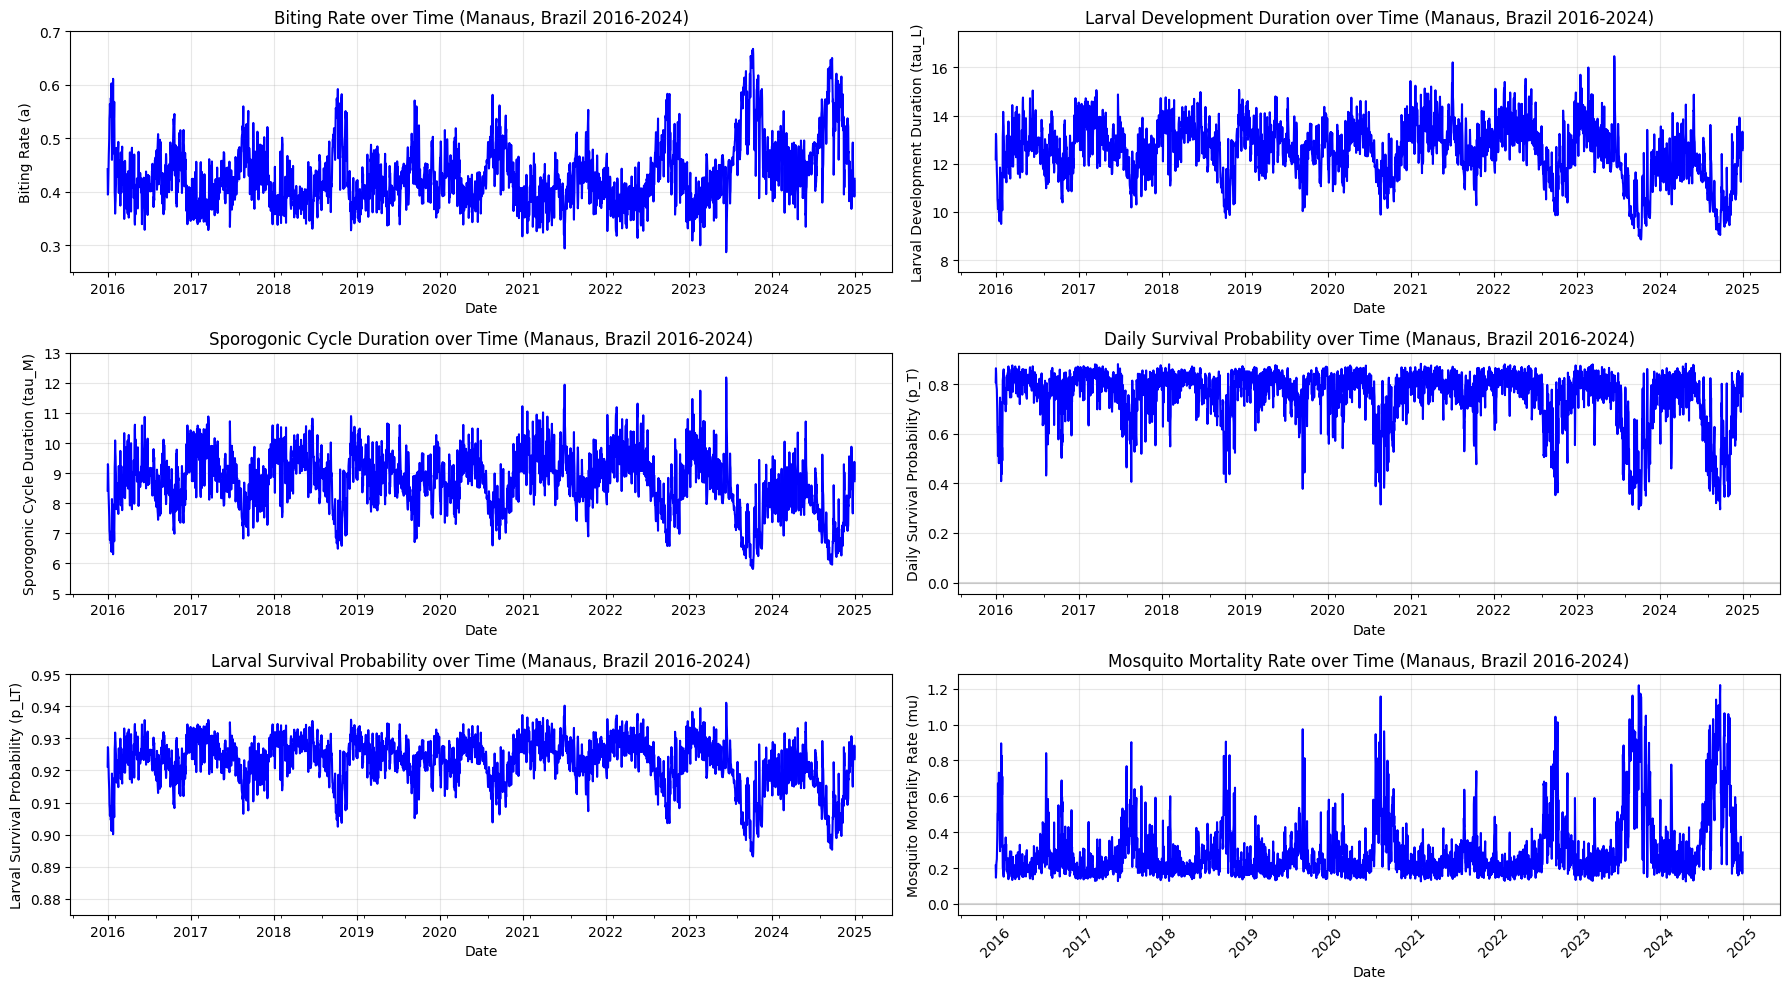

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.25, 0.7)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
for ax in axes.flatten():  # Use .flat to iterate over all subplots in 2D array
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### We know that the $R_0$ of SEIRS is given by $\frac{ab_2}{\gamma}$. Let's check the evolution of it:

In [10]:
temp_t0 = climate_data[climate_data['date']=='2017-01-01']['temp_med'] ### temp_med at 2017-01-01, first day of the SEIRS-SEI analysis

In [11]:
a_temp_t0 = a(temp_t0)
a_temp_t0 = round(float(a_temp_t0[0]), 3)
print(f'At the start of analysis, the biting rate is of {a_temp_t0} bites/mosquito/night')

At the start of analysis, the biting rate is of 0.352 bites/mosquito/night


In [12]:
R0 = a_temp_t0*b2/gamma
print(f'The value of R0, when b2={b2}, is {R0}')

The value of R0, when b2=0.09, is 3.8016


In [13]:
b2_R0_1 = gamma/a_temp_t0
b2_R0_1 = round(b2_R0_1, 3)

print(f'The value of R0 is 1 when b2 \u2248 {b2_R0_1}')

The value of R0 is 1 when b2 ≈ 0.024


In [14]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-01-01', '2024-12-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_min'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

(array([19417., 19601., 19783., 19967.]),
 [Text(19417.0, 0, 'Mar 2023'),
  Text(19601.0, 0, 'Sep 2023'),
  Text(19783.0, 0, 'Mar 2024'),
  Text(19967.0, 0, 'Sep 2024')])

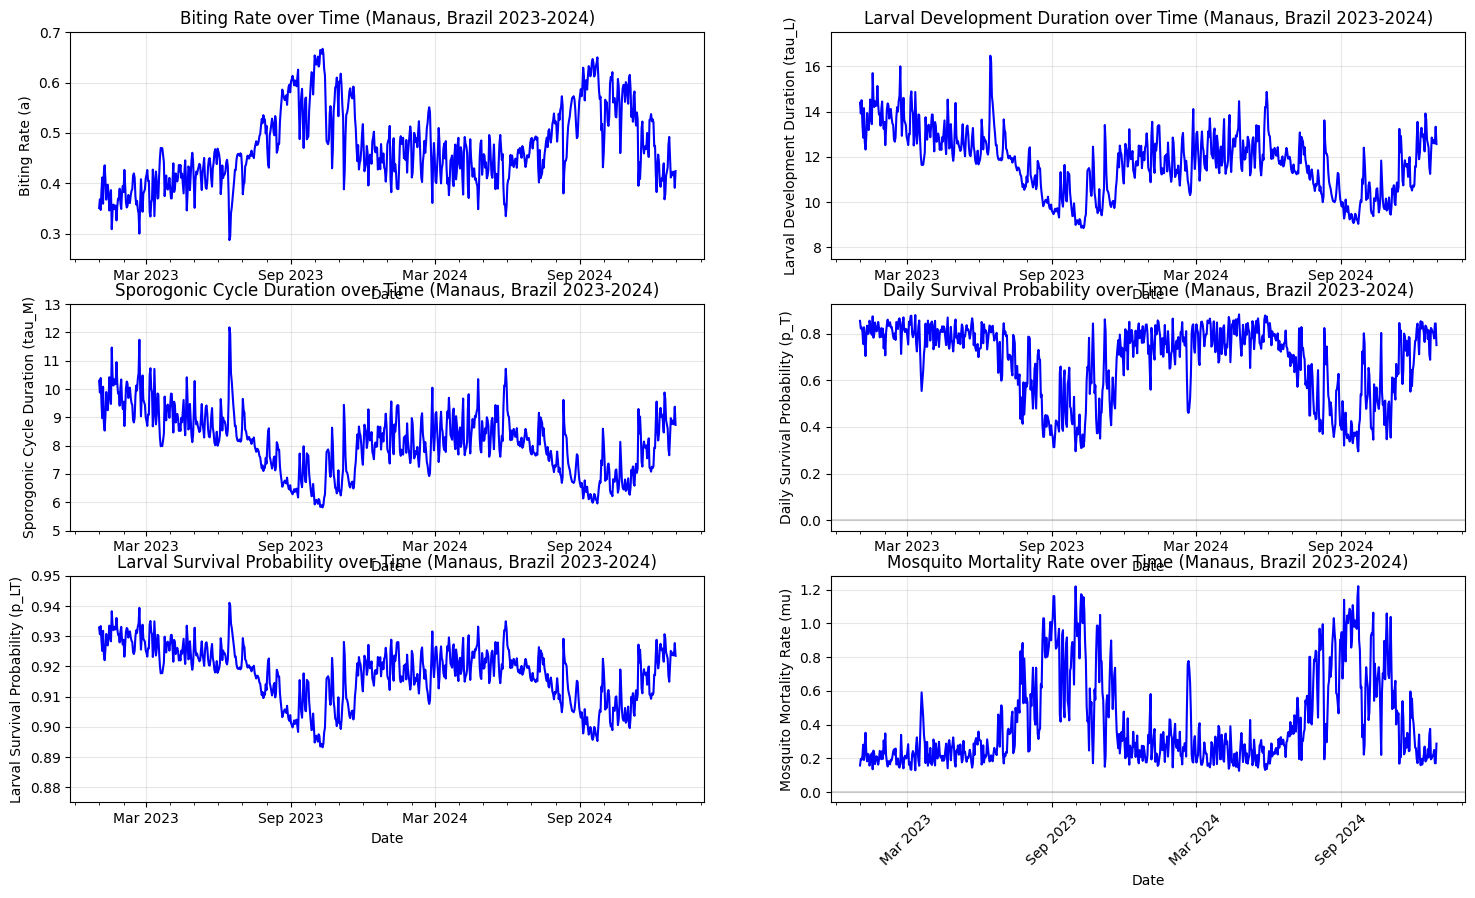

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.25, 0.7)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
for ax in axes.flat:
    # Set major ticks every 6 months with year
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # "Jan 2023"
    
    # Set minor ticks every month without labels
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
    
plt.xticks(rotation=45)

In [16]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-07-01', '2023-12-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_min'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

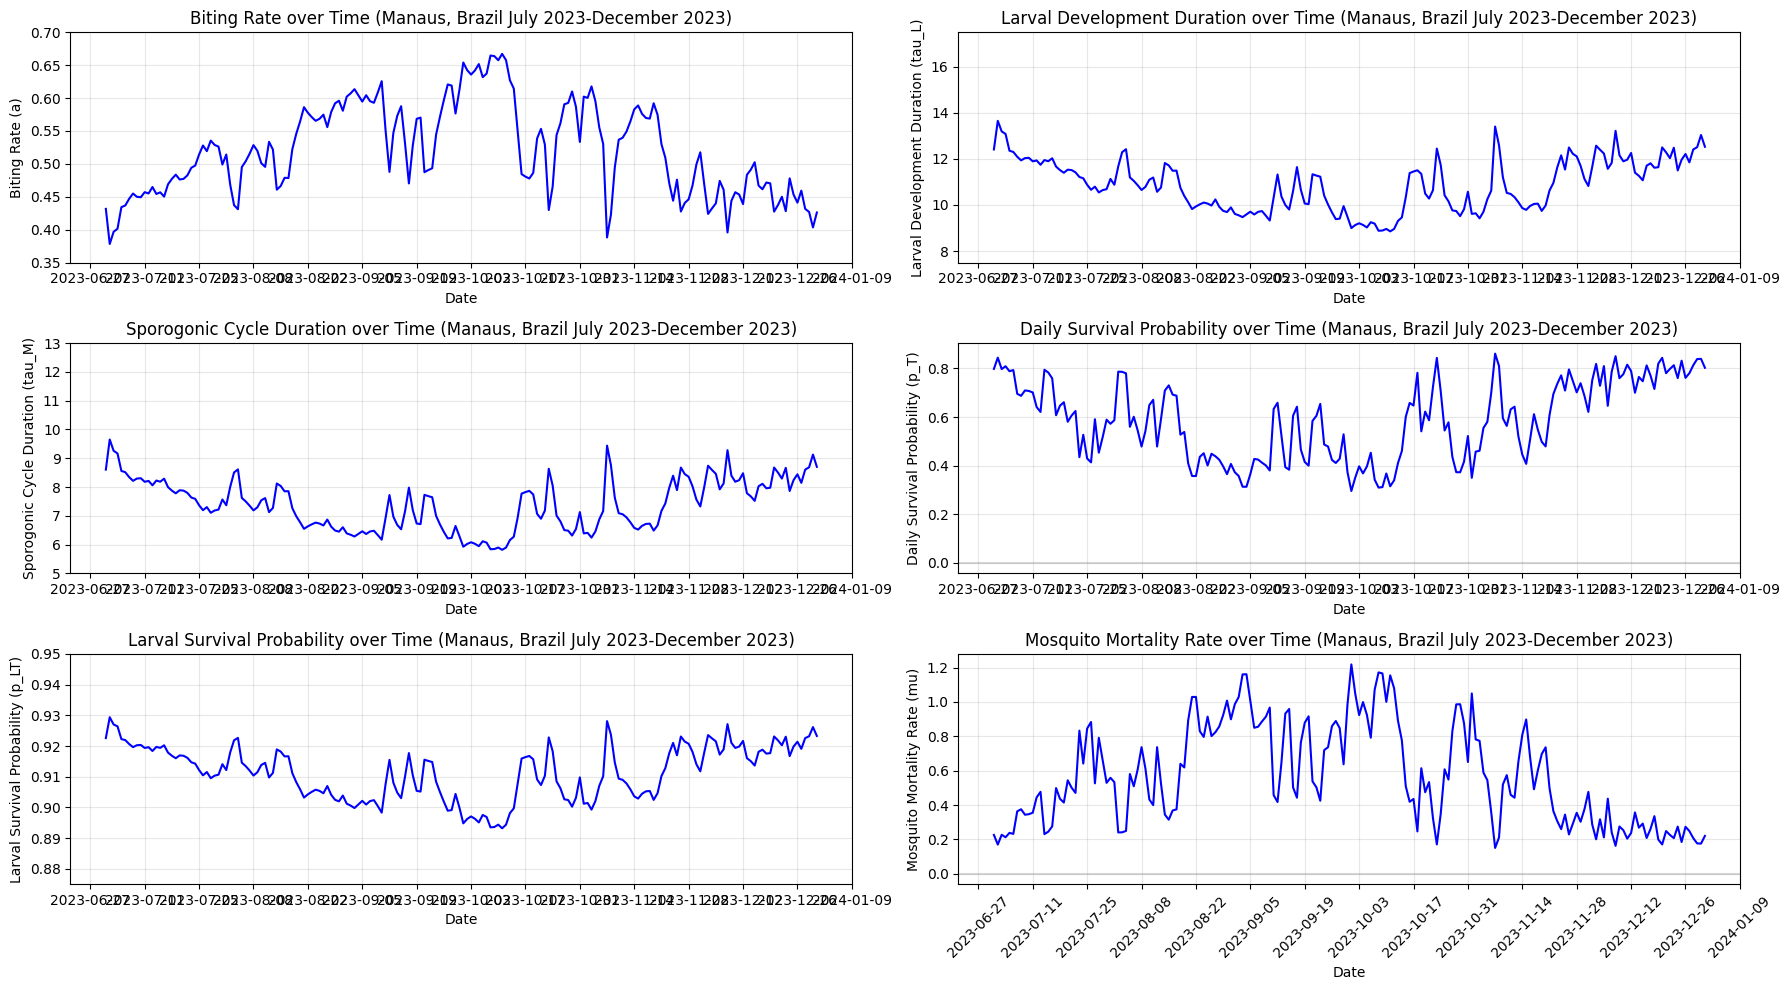

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.35, 0.7)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
import matplotlib.dates as mdates
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # Every 2 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-08-01', '2023-10-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_min'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

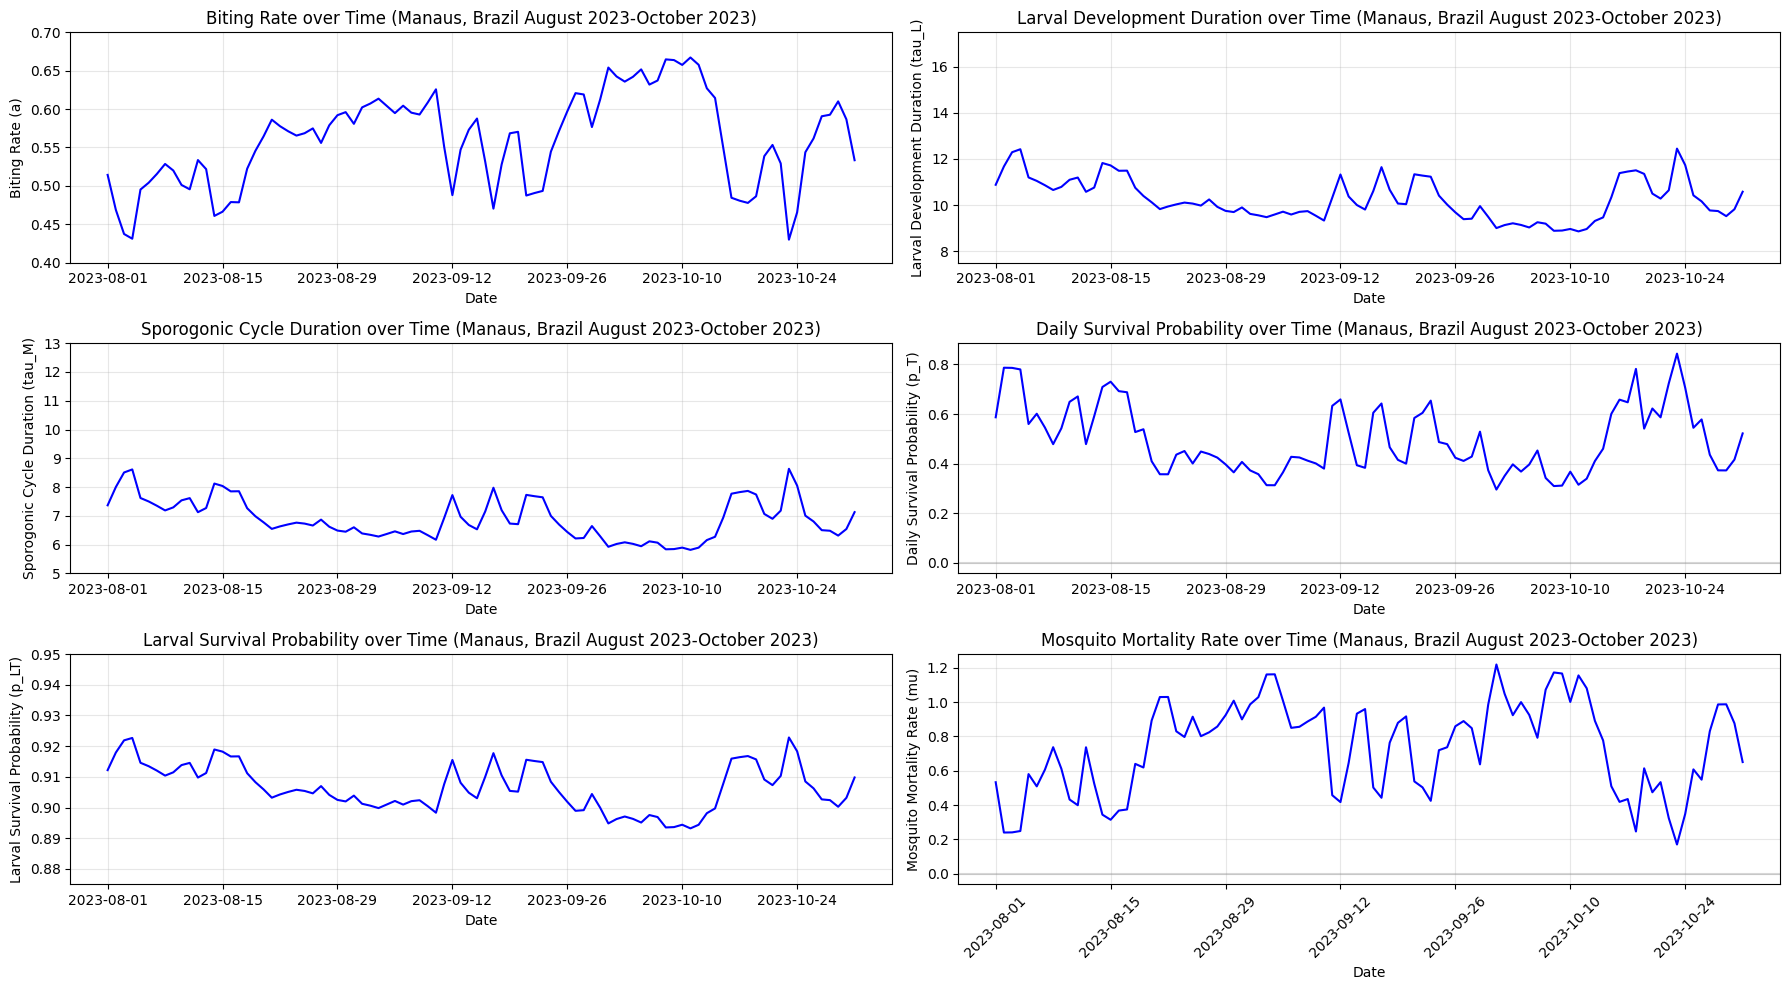

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 0.7)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
import matplotlib.dates as mdates
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # Every 2 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
climate_data['date'] = pd.to_datetime(climate_data['date'])

# Use the actual temperature data from your climate dataset
date_range = climate_data['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_min'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

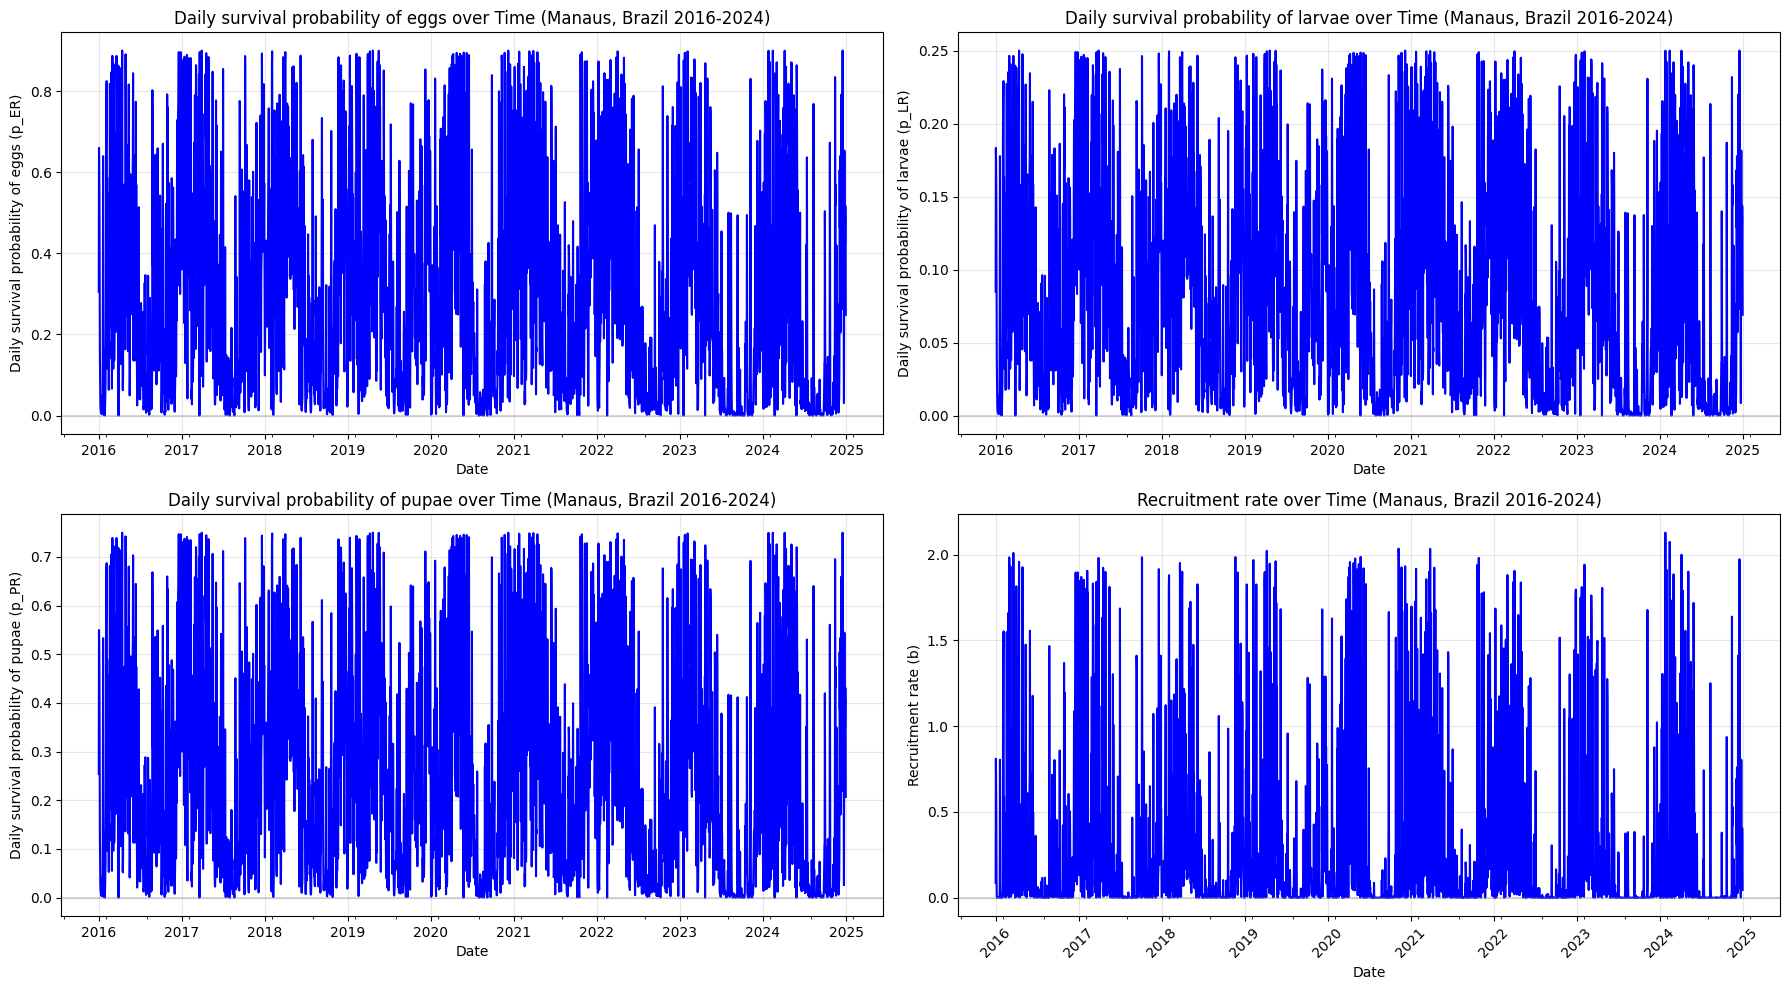

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1) Plot p_ER vs time
p_ER_over_time = p_ER(rain_actual, R_L)

ax = axes[0, 0]
ax.plot(date_range, p_ER_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily survival probability of eggs (p_ER)')
ax.set_title('Daily survival probability of eggs over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(0.05, 0.4)  

# 2) Plot p_LR vs time
p_LR_over_time = p_LR(rain_actual, R_L)

ax = axes[0, 1]
ax.plot(date_range, p_LR_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily survival probability of larvae (p_LR)')
ax.set_title('Daily survival probability of larvae over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(0.05, 0.4)  

# 3) Plot p_PR vs time
p_PR_over_time = p_PR(rain_actual, R_L)

ax = axes[1, 0]
ax.plot(date_range, p_PR_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily survival probability of pupae (p_PR)')
ax.set_title('Daily survival probability of pupae over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(0.05, 0.4)  

# 4) Plot b vs time 
b_over_time = b_rate(rain_actual, temp_actual, R_L)

ax = axes[1, 1]
ax.plot(date_range, b_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Recruitment rate (b)')
ax.set_title('Recruitment rate over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)


# Simplify x-axis for both subplots
for ax in axes.flatten():  # Use .flat to iterate over all subplots in 2D array
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()